# 08: Tract Clustering: Who Actually Gains and Loses Access

`03_comparison_cities_demographics.ipynb` found Gotham's reachable population shifts +21.2pp
whiter and +39% wealthier -- one aggregate before/after number. This notebook recomputes that
finding at tract-cluster resolution, and under three different ways of counting "reachable,"
since the choice turned out to change the answer materially:

1. **Hard cutoff, 60 min** -- population counts fully if the tract is within 60 min, zero otherwise.
2. **Hard cutoff, 90 min** -- same, wider boundary (uses `06_nyc_isochrones.ipynb`'s
   corrected walking speed + 90-min threshold).
3. **Distance-decay weighted** -- no cliff. Population counted at `exp(-ln(2) * t / 30)`, i.e. a
   tract at 30 min counts half as much as one at the stadium door, 60 min counts a quarter, 90
   min an eighth. This is the version to lead with in the paper -- it doesn't depend on an
   arbitrary threshold, and running all three side by side is itself the finding: the *direction*
   (lower-income NJ clusters lose share, a higher-income cluster with closer transit reach gains) is
   robust across all three; *which* cluster looks flat vs. losing (the Black-plurality NJ
   cluster in particular) is not, and only the decay-weighted version avoids that instability.

**Inputs:** `data/raw/census/acs_demographics_ny_nj.csv`,
`data/processed/nyc_tract_travel_times_90min.csv` (transit+walk, corrected speed),
`data/raw/census/tl_2023_{36,34}_tract.zip` (vendored locally from `nwsl_transportation`).

**Outputs:** `output/tract_clusters_{60min,90min,weighted}.csv`,
`output/cluster_composition_shift_{60min,90min,weighted}.csv`,
`output/tract_cluster_map_{60min,90min,weighted}.png`.

**Method:** k-means on standardized per-tract features (demographic + accessibility), k chosen
via elbow + silhouette, run once per weighting scheme below so the three are directly
comparable.


In [1]:
import os

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import contextily as cx

from plot_theme import set_mpl_theme, NWSL_PALETTE
set_mpl_theme()

OUTPUT_DIR = os.path.join("..", "..", "output")
os.makedirs(OUTPUT_DIR, exist_ok=True)
# vendored locally (data/raw/census), no dependency on the sibling nwsl_transportation project
TRANSPORTATION_CENSUS = os.path.join("..", "..", "data", "raw", "census")
DATA_PROCESSED_DIR = os.path.join("..", "..", "data", "processed")

RNG_SEED = 42
N_CLUSTERS = 4
DATA_MAX_MIN = 90  # r5py isochrones only computed out to 90 min -- a data-extent limit, not a modeling choice
FEATURE_COLS = [
    "median_household_income", "median_age",
    "pct_white_nh", "pct_black_nh", "pct_asian_nh", "pct_hispanic_latino",
    "transit_time_current", "transit_time_future",
]
MAP_BOUNDS = (-74.6, 40.45, -73.4, 41.05)

## Step 1: assemble the per-tract feature table (shared across all three scenarios)

One row per Census tract: demographic shares/levels from ACS, plus transit+walk travel time to
Red Bull Arena ("current") and Etihad Park ("future"), built with the corrected walking speed
(`06`'s `speed_walking=5.0`, not r5py's default). Scoped to the full 90-min data extent -- each
scenario below then decides how much of that extent actually counts.


In [2]:
acs = pd.read_csv(os.path.join(TRANSPORTATION_CENSUS, "acs_demographics_ny_nj.csv"), dtype={"GEOID": str})
for col in ["population", "median_household_income", "median_age", "white_nh", "black_nh", "asian_nh", "hispanic_latino"]:
    acs[col] = pd.to_numeric(acs[col], errors="coerce")
acs["pct_white_nh"] = 100 * acs["white_nh"] / acs["population"]
acs["pct_black_nh"] = 100 * acs["black_nh"] / acs["population"]
acs["pct_asian_nh"] = 100 * acs["asian_nh"] / acs["population"]
acs["pct_hispanic_latino"] = 100 * acs["hispanic_latino"] / acs["population"]
acs_features = acs[[
    "GEOID", "population", "median_household_income", "median_age",
    "pct_white_nh", "pct_black_nh", "pct_asian_nh", "pct_hispanic_latino",
]].copy()

def load_travel_times(path, mode_label, site_filter=None):
    df = pd.read_csv(path, dtype={"GEOID": str})
    if site_filter is not None:
        df = df[df["site_label"].isin(site_filter)]
    df = df.groupby(["GEOID", "site_label"], as_index=False)["travel_time_minutes"].mean()
    wide = df.pivot(index="GEOID", columns="site_label", values="travel_time_minutes")
    wide.columns = [f"{mode_label}_time_{c}" for c in wide.columns]
    return wide.reset_index()

travel = load_travel_times(
    os.path.join(DATA_PROCESSED_DIR, "nyc_tract_travel_times_90min.csv"), "transit",
    site_filter=["current", "future"],  # drop yankee_stadium/citi_field rows, not part of this clustering
)
travel["delta_transit_time"] = travel["transit_time_future"] - travel["transit_time_current"]

features = acs_features.merge(travel, on="GEOID", how="inner")
in_scope = (features["transit_time_current"] <= DATA_MAX_MIN) | (features["transit_time_future"] <= DATA_MAX_MIN)
scoped = features[in_scope].copy()
total_metro_population = acs_features["population"].sum()
print(f"{len(scoped)} tracts within {DATA_MAX_MIN}-min data extent of either stadium")

2440 tracts within 90-min data extent of either stadium


## Step 2: cluster once on the full 90-min extent

Clustering itself (which tract belongs to which demographic/accessibility cluster) doesn't
depend on the weighting scheme -- only *how much each tract's population counts* toward the
composition-shift numbers does. So k-means runs once here; the three scenarios below just
re-aggregate the same cluster assignments differently.

In [3]:
model_df = scoped.dropna(subset=FEATURE_COLS).reset_index(drop=True)
print(f"Clustering on {len(model_df)} tracts")

X = StandardScaler().fit_transform(model_df[FEATURE_COLS])
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RNG_SEED, n_init=10).fit(X)
    print(f"k={k} inertia={km.inertia_:.0f} silhouette={silhouette_score(X, km.labels_):.3f}")

Clustering on 2218 tracts


k=2 inertia=13683 silhouette=0.224
k=3 inertia=11514 silhouette=0.228
k=4 inertia=9526 silhouette=0.255
k=5 inertia=8449 silhouette=0.269


k=6 inertia=7667 silhouette=0.254
k=7 inertia=7189 silhouette=0.258
k=8 inertia=6723 silhouette=0.255


In [4]:
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=RNG_SEED, n_init=10).fit(X)
model_df["cluster"] = kmeans.labels_
centroids = pd.DataFrame(StandardScaler().fit(model_df[FEATURE_COLS]).inverse_transform(kmeans.cluster_centers_), columns=FEATURE_COLS)

names = {}
for i, row in centroids.iterrows():
    tags = ["higher-income" if row["median_household_income"] > centroids["median_household_income"].median() else "lower-income"]
    race_cols = {"white_nh": "pct_white_nh", "black_nh": "pct_black_nh", "asian_nh": "pct_asian_nh", "hispanic/latino": "pct_hispanic_latino"}
    dom = max(race_cols, key=lambda k: row[race_cols[k]])
    tags.append(f"{dom}-plurality")
    tags.append("closer reach" if row["transit_time_future"] <= centroids["transit_time_future"].median() else "farther reach")
    names[i] = ", ".join(tags)

model_df["cluster_name"] = model_df["cluster"].map(names)
print(centroids.round(1).to_string())
print()
print(names)

   median_household_income  median_age  pct_white_nh  pct_black_nh  pct_asian_nh  pct_hispanic_latino  transit_time_current  transit_time_future
0                  84230.0        42.5          20.6           7.0          41.5                 24.3                  95.1                 51.8
1                  73711.5        38.1           7.8          66.1           3.8                 16.0                  84.7                 80.5
2                  59270.9        36.0          12.5          16.7           6.4                 60.9                  83.5                 71.1
3                 130937.2        37.5          60.0           5.6          13.0                 16.1                  78.6                 64.7

{0: 'higher-income, asian_nh-plurality, closer reach', 1: 'lower-income, black_nh-plurality, farther reach', 2: 'lower-income, hispanic/latino-plurality, farther reach', 3: 'higher-income, white_nh-plurality, closer reach'}


## Step 3: three weighting scenarios, one function

`weight_fn(travel_time_minutes) -> [0, 1]` is the only thing that differs between scenarios.

In [5]:
def hard_cutoff(threshold):
    return lambda t: np.where(t <= threshold, 1.0, 0.0)

def decay(half_life_min):
    beta = np.log(2) / half_life_min
    return lambda t: np.exp(-beta * t)

SCENARIOS = {
    "60min":    {"weight_fn": hard_cutoff(60), "label": "Hard cutoff, 60 min"},
    "90min":    {"weight_fn": hard_cutoff(90), "label": "Hard cutoff, 90 min"},
    "weighted": {"weight_fn": decay(30),       "label": "Distance-decay, 30-min half-life"},
}

results = {}
for scenario_id, cfg in SCENARIOS.items():
    df = model_df.copy()
    w = cfg["weight_fn"]
    df["weight_current"] = np.where(df["transit_time_current"].notna(), w(df["transit_time_current"]), 0.0)
    df["weight_future"] = np.where(df["transit_time_future"].notna(), w(df["transit_time_future"]), 0.0)
    df["weighted_pop_current"] = df["population"] * df["weight_current"]
    df["weighted_pop_future"] = df["population"] * df["weight_future"]

    comparison = df.groupby("cluster_name")[["weighted_pop_current", "weighted_pop_future"]].sum()
    comparison["change"] = comparison["weighted_pop_future"] - comparison["weighted_pop_current"]
    comparison["pct_of_future_total"] = 100 * comparison["weighted_pop_future"] / comparison["weighted_pop_future"].sum()
    comparison["pct_of_current_total"] = 100 * comparison["weighted_pop_current"] / comparison["weighted_pop_current"].sum()
    comparison["pct_point_shift"] = comparison["pct_of_future_total"] - comparison["pct_of_current_total"]
    comparison = comparison.sort_values("pct_point_shift")

    df.to_csv(os.path.join(OUTPUT_DIR, f"tract_clusters_{scenario_id}.csv"), index=False)
    comparison.to_csv(os.path.join(OUTPUT_DIR, f"cluster_composition_shift_{scenario_id}.csv"))
    results[scenario_id] = {"df": df, "comparison": comparison}
    print(f"=== {cfg['label']} ===")
    print(comparison.round(1).to_string())
    print()

=== Hard cutoff, 60 min ===
                                                        weighted_pop_current  weighted_pop_future     change  pct_of_future_total  pct_of_current_total  pct_point_shift
cluster_name                                                                                                                                                            
lower-income, black_nh-plurality, farther reach                     317141.0             167852.0  -149289.0                  5.5                  30.9            -25.4
lower-income, hispanic/latino-plurality, farther reach              363285.0             504280.0   140995.0                 16.5                  35.4            -19.0
higher-income, white_nh-plurality, closer reach                     315938.0            1362231.0  1046293.0                 44.4                  30.8             13.7
higher-income, asian_nh-plurality, closer reach                      29679.0            1030472.0  1000793.0                 33

=== Distance-decay, 30-min half-life ===
                                                        weighted_pop_current  weighted_pop_future    change  pct_of_future_total  pct_of_current_total  pct_point_shift
cluster_name                                                                                                                                                           
lower-income, black_nh-plurality, farther reach                     292696.7             295988.5    3291.8                 14.3                  20.9             -6.6
lower-income, hispanic/latino-plurality, farther reach              447391.4             588719.4  141328.0                 28.4                  31.9             -3.4
higher-income, white_nh-plurality, closer reach                     480482.0             655302.8  174820.8                 31.7                  34.2             -2.6
higher-income, asian_nh-plurality, closer reach                     182464.8             530124.6  347659.8            

## Step 4: side-by-side comparison table

The pct-point shift, all three scenarios, one table -- this is the actual deliverable figure.

In [6]:
side_by_side = pd.concat(
    {cfg["label"]: results[sid]["comparison"]["pct_point_shift"] for sid, cfg in SCENARIOS.items()},
    axis=1,
)
side_by_side.to_csv(os.path.join(OUTPUT_DIR, "cluster_shift_scenario_comparison.csv"))
side_by_side.round(1)

,"Hard cutoff, 60 min","Hard cutoff, 90 min","Distance-decay, 30-min half-life"
cluster_name,,,
"lower-income, black_nh-plurality, farther reach",-25.4,-0.8,-6.6
"lower-income, hispanic/latino-plurality, farther reach",-19.0,-1.4,-3.4
"higher-income, white_nh-plurality, closer reach",13.7,-7.5,-2.6
"higher-income, asian_nh-plurality, closer reach",30.7,9.8,12.6


## Step 5: map the headline scenario

Only the decay-weighted scenario gets a rendered map -- it's the one to lead with (Step 6). The 60-min and 90-min hard-cutoff scenarios are still fully computed above and appear in the Step 4 comparison table; they don't get their own maps, since the table already carries everything a robustness check needs, and a third and fourth map would just be more figures to explain for the same underlying point.

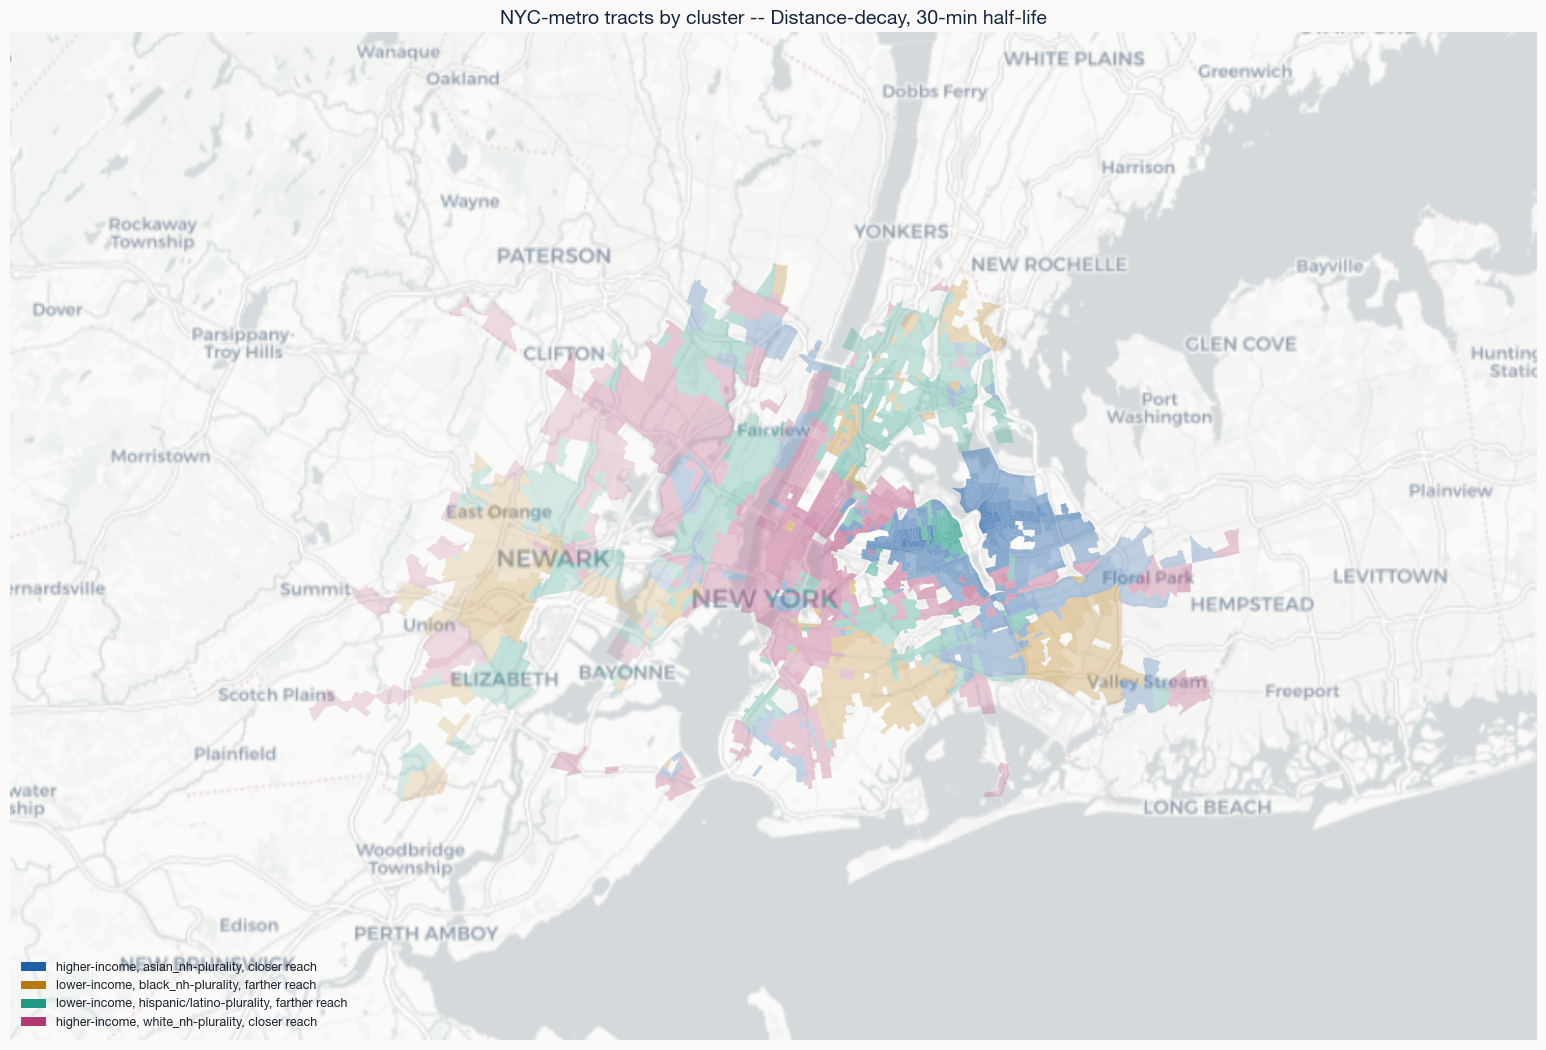

Saved ../../output/tract_cluster_map_weighted.png


In [7]:
def draw_map(scenario_id, cfg, use_alpha_gradient):
    df = results[scenario_id]["df"]
    tract_frames = []
    for zip_name in ["tl_2023_36_tract.zip", "tl_2023_34_tract.zip"]:
        tracts = gpd.read_file(f"zip://{os.path.join(TRANSPORTATION_CENSUS, zip_name)}")
        tract_frames.append(tracts)
    tracts = pd.concat(tract_frames, ignore_index=True)
    tracts = gpd.GeoDataFrame(tracts, crs=tract_frames[0].crs).to_crs("EPSG:4326")
    tracts["GEOID"] = tracts["GEOID"].astype(str)

    if use_alpha_gradient:
        merged = tracts.merge(df[["GEOID", "cluster", "cluster_name", "weight_future"]], on="GEOID", how="inner")
    else:
        in_scope_rows = df[df["weight_future"] > 0]
        merged = tracts.merge(in_scope_rows[["GEOID", "cluster", "cluster_name"]], on="GEOID", how="inner")

    fig, ax = plt.subplots(figsize=(16, 10.6))
    ax.set_xlim(MAP_BOUNDS[0], MAP_BOUNDS[2])
    ax.set_ylim(MAP_BOUNDS[1], MAP_BOUNDS[3])
    cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron, attribution=False)

    cluster_ids = sorted(model_df["cluster"].unique())
    colors = dict(zip(cluster_ids, NWSL_PALETTE[:N_CLUSTERS]))

    if use_alpha_gradient:
        merged["alpha_bin"] = (0.12 + 0.83 * merged["weight_future"].clip(0, 1))
        merged["alpha_bin"] = (merged["alpha_bin"] * 12).round() / 12
        for cid in cluster_ids:
            sub_cluster = merged[merged["cluster"] == cid]
            for abin, sub in sub_cluster.groupby("alpha_bin"):
                sub.plot(ax=ax, color=colors[cid], alpha=abin, edgecolor="none")
    else:
        for cid in cluster_ids:
            merged[merged["cluster"] == cid].plot(ax=ax, color=colors[cid], alpha=0.75, edgecolor="white", linewidth=0.2)

    legend_handles = [Patch(facecolor=colors[c], label=names[c]) for c in cluster_ids]
    ax.legend(handles=legend_handles, loc="lower left", fontsize=9, framealpha=0.9)
    ax.set_title(f"NYC-metro tracts by cluster -- {cfg['label']}", fontsize=14)
    ax.set_axis_off()
    plt.tight_layout()
    out_path = os.path.join(OUTPUT_DIR, f"tract_cluster_map_{scenario_id}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Saved {out_path}")

# Only the headline (decay-weighted) scenario gets a rendered map -- see the markdown above.
draw_map("weighted", SCENARIOS["weighted"], use_alpha_gradient=True)

## Takeaway for the paper

Lead with the **decay-weighted** scenario -- it doesn't depend on picking an arbitrary threshold,
and it gives the most decisive version of the finding (every other cluster loses relative share,
the higher-income Asian-plurality cluster near Willets Point is the sole clear beneficiary).
Only the decay-weighted map is rendered below (Step 5) -- the 60-min and 90-min hard-cutoff
versions are still computed (Step 3) and appear in the one side-by-side table (Step 4) as a
robustness check, not as three co-equal maps to explain: they agree on direction, but disagree
on magnitude and on whether the Black-plurality NJ cluster is meaningfully affected at all --
worth stating as an explicit caveat, not walking through three full figures.
